In [1]:
import ast
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dill
from configs.data_constants_config import ALPHA

import mlflow
import mlflow.sklearn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
#Data loading
path = '/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/artifacts/'
X_train = pd.read_csv(os.path.join(path, 'X_train_proper.csv'))
y_train = pd.read_csv(os.path.join(path, 'y_train_proper.csv')).values.ravel()
X_cal = pd.read_csv(os.path.join(path, 'X_cal.csv'))
y_cal = pd.read_csv(os.path.join(path, 'y_cal.csv')).values.ravel()
X_test = pd.read_csv(os.path.join(path, 'X_test_processed.csv'))
y_test = pd.read_csv(os.path.join(path, 'y_test.csv')).values.ravel()

#Top 5 models after hyperparameter tuning
top_df = pd.read_csv(os.path.join(path, 'top2_gp_models.csv'))

print('Top model (ranked by RMSE - MAE - R square):')
display(top_df[['model','test_rmse','test_mae','test_r2','best_params']])

Top model (ranked by RMSE - MAE - R square):


,model,test_rmse,test_mae,test_r2,best_params
0,Gaussian Process,17.562538,12.220109,0.807928,"{'alpha': 0.5, 'kernel': Matern(length_scale=1..."


In [3]:
X_train_gp = X_train.copy()
y_train_gp = y_train.copy()

X_test_gp = X_test.copy()
y_test_gp = y_test.copy()

'''
#Downsampling method 1 - Discarded because it gives poor coverage, overconfident predictions and does not capture aleatoric uncertainty of sesnor data
if len(X_train_gp) > 2500:
    step = len(X_train_gp) // 2500
    X_train_gp = X_train_gp.iloc[::step].reset_index(drop=True)
    y_train_gp = y_train_gp[::step]

if len(X_test_gp) > 1000:
    step = len(X_test_gp) // 1000
    X_test_gp = X_test_gp.iloc[::step].reset_index(drop=True)
    y_test_gp = y_test_gp[::step]


#Downsampling method 2 - Random sampling to reduce training size to 2500 samples
X_train_gp = X_train.sample(n=2500, random_state=42)
y_train_gp = y_train[X_train_gp.index]
'''

#Downsampling method 3 - Using landmark selection to reduce training size to 2500 samples
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2500, random_state=42)
cluster_labels = kmeans.fit_predict(X_train)
X_train_gp = pd.DataFrame(kmeans.cluster_centers_,columns=X_train.columns)
y_train_gp = np.array([y_train[cluster_labels == i].mean()for i in range(2500)])


In [4]:
print("Training samples:", len(X_train))
print("Unique samples:", len(np.unique(X_train, axis=0)))
print("Requested clusters:", 2500)
print("Clusters actually used:", len(np.unique(cluster_labels)))


Training samples: 16778
Unique samples: 16778
Requested clusters: 2500
Clusters actually used: 2500


In [5]:
print(f"Training on {len(X_train_gp)} samples")
print(f"Testing  on {len(X_test_gp)} samples")

Training on 2500 samples
Testing  on 100 samples


In [ ]:
#1. Tell MLflow the name of your overall project/experiment
mlflow.set_experiment("RUL_Prediction")

#2. Start a tracking "Run"
with mlflow.start_run():
    
    #Define the hyperparameters for the GP model
    initial_scales = [1.0] * 10 
    current_alpha = 0.01
    current_nu = 2.5
    
    #Log the hyperparameters to MLflow
    mlflow.log_param("alpha", current_alpha)
    mlflow.log_param("matern_nu", current_nu)
    mlflow.log_param("length_scale", initial_scales)
    
    #Initialize and fit the model
    gp_model = GaussianProcessRegressor(
        kernel=Matern(length_scale=initial_scales, nu=current_nu),
        alpha=current_alpha, 
        random_state=42 
    )
    gp_model.fit(X_train_gp, y_train_gp)
    
    #Predict
    y_pred, sigma = gp_model.predict(X_test_gp, return_std=True)

    #Intervals for the predictions
    #For a 95% CI, we use Z = 1.96
    z_score = 1.96
    lower_bound = y_pred - (z_score * sigma)
    upper_bound = y_pred + (z_score * sigma)
    
    # Metric A: Interval Width (Upper Bound minus Lower Bound)
    widths = upper_bound - lower_bound
    mean_interval_width = np.mean(widths)
    
    # Metric B: Coverage (What % of actual values fall inside the bounds?)
    inside_interval = (y_test_gp >= lower_bound) & (y_test_gp <= upper_bound)
    coverage = np.mean(inside_interval) # Returns a decimal between 0 and 1

    # Calculate metrics
    rmse = mean_squared_error(y_test_gp, y_pred) ** 0.5
    mae = mean_absolute_error(y_test_gp, y_pred)
    r2 = r2_score(y_test_gp, y_pred)
    
    #Log metrics to MLflow
    # This records how well this specific recipe performed
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)

    # Log your brand new uncertainty metrics!
    mlflow.log_metric("mpiw_width", mean_interval_width)
    mlflow.log_metric("picp_coverage", coverage)
    
    # Log the model itself
    #mlflow.sklearn.log_model(gp_model, "gp_rul_model")
    
    print("="*60)
    print(f"Accuracy Metrics:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")
    print("-"*60)
    print(f"Uncertainty Metrics (95% CI):")
    print(f"  • PICP (Coverage): {coverage*100:.2f}%")
    print(f"  • MPIW (Mean Width): {mean_interval_width:.4f}")
    print("="*60)

# Using the best model

## Plot 1: Point predictions + intervals 

In [122]:
from scipy.stats import norm

ALPHA = ALPHA
NOMINAL = 1 - ALPHA

z = norm.ppf(1 - ALPHA / 2)
y_pred, y_std = gp_model.predict(X_test_gp, return_std = True)

# 90% predictive interval
lower = y_pred - z * y_std
upper = y_pred + z * y_std

coverage = np.mean((y_test_gp >= lower) & (y_test_gp <= upper))
avg_width = np.mean(upper - lower)

print(f"Empirical coverage: {coverage:.3f}")
print(f"Average width: {avg_width:.3f}")

Empirical coverage: 0.070
Average width: 1.786


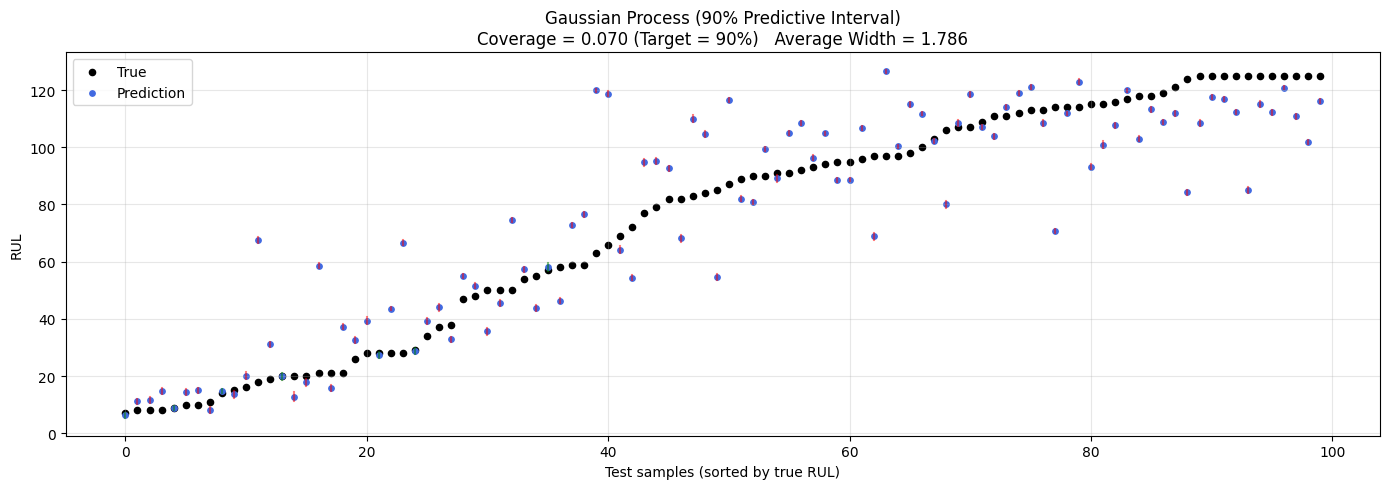

In [123]:
MAX_POINTS = 80

sort_idx = np.argsort(y_test_gp)
step = max(1, len(y_test_gp) // MAX_POINTS)

idx = sort_idx[::step]

y_true = y_test_gp[idx]
y_hat = y_pred[idx]

lo = lower[idx]
hi = upper[idx]

covered = (y_true >= lo) & (y_true <= hi)

x_pos = np.arange(len(idx))

fig, ax = plt.subplots(figsize=(14, 5))

for xi, l, h, cov in zip(x_pos, lo, hi, covered):

    ax.plot(
        [xi, xi],
        [l, h],
        color='green' if cov else 'red',
        linewidth=1.5,
        alpha=0.5
    )

ax.scatter(
    x_pos,
    y_true,
    color='black',
    s=20,
    label='True'
)

ax.scatter(
    x_pos,
    y_hat,
    color='royalblue',
    s=15,
    label='Prediction'
)

ax.set_xlabel("Test samples (sorted by true RUL)")
ax.set_ylabel("RUL")

ax.set_title(
    f"Gaussian Process (90% Predictive Interval)\n"
    f"Coverage = {coverage:.3f} (Target = {NOMINAL:.0%})   "
    f"Average Width = {avg_width:.3f}"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(path, "gp_prediction_intervals.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

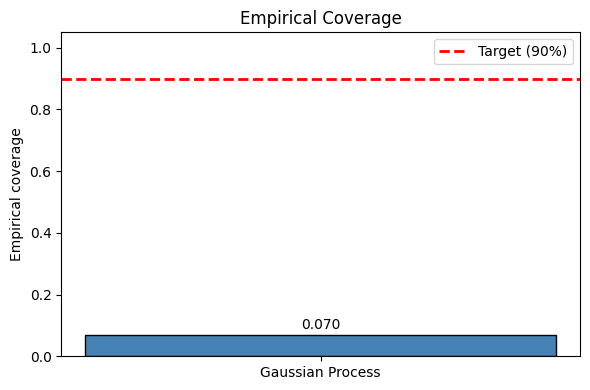

In [124]:
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(
    ['Gaussian Process'],
    [coverage],
    color='steelblue',
    edgecolor='black'
)

ax.axhline(
    NOMINAL,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Target ({NOMINAL:.0%})'
)

ax.text(
    bars[0].get_x() + bars[0].get_width()/2,
    coverage + 0.02,
    f"{coverage:.3f}",
    ha='center'
)

ax.set_ylim(0,1.05)
ax.set_ylabel("Empirical coverage")
ax.set_title("Empirical Coverage")

ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(path, "gp_empirical_coverage.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

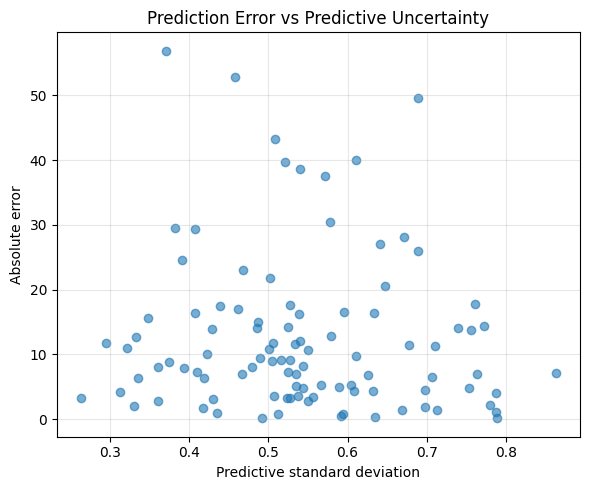

In [125]:
abs_error = np.abs(y_pred - y_test_gp)

plt.figure(figsize=(6,5))

plt.scatter(
    y_std,
    abs_error,
    alpha=0.6
)

plt.xlabel("Predictive standard deviation")
plt.ylabel("Absolute error")

plt.title("Prediction Error vs Predictive Uncertainty")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(path, "gp_error_vs_uncertainty.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

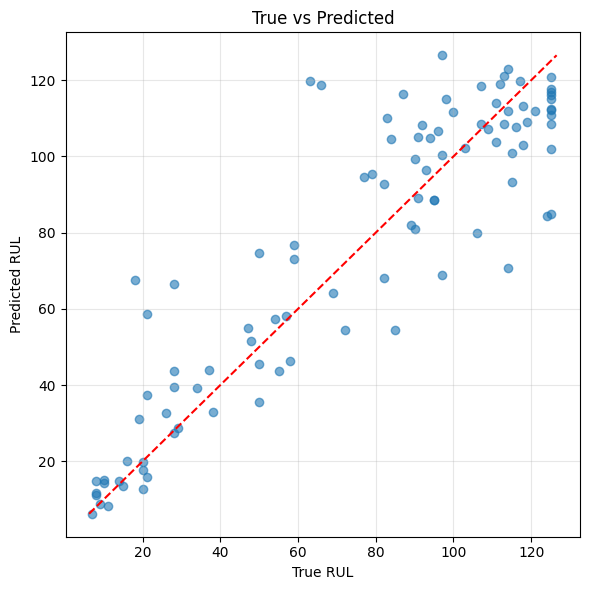

In [126]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test_gp,
    y_pred,
    alpha=0.6
)

mn = min(y_test_gp.min(), y_pred.min())
mx = max(y_test_gp.max(), y_pred.max())

plt.plot(
    [mn, mx],
    [mn, mx],
    'r--'
)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")

plt.title("True vs Predicted")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(path, "gp_true_vs_predicted.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [127]:

summary = pd.DataFrame({
    "Model": ["Gaussian Process"],
    "Coverage": [coverage],
    "Average Interval Width": [avg_width]
})

print(f"Nominal Coverage = {NOMINAL:.0%}")
print(f"Test Size = {len(y_test_gp)}\n")

display(summary)


Nominal Coverage = 90%
Test Size = 100



,Model,Coverage,Average Interval Width
0,Gaussian Process,0.07,1.786329
